In [5]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pickle
from pathlib import Path
from typing import Tuple
from datetime import datetime
# import lifelines coxphitter

from lifelines import CoxPHFitter

#add path path to data folder using sys.path
sys.path.append('../data_process/')
from data_process import load_dataset
from helpers import * 

import warnings
warnings.filterwarnings('ignore')

palette = sns.husl_palette(h=.7)
rc = {
    'figure.dpi': 300,
    'font.size': 6,
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'axes.labelsize': 6,  
    'legend.fontsize': 6,
    'axes.titlesize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'axes.edgecolor': 'k',
    'axes.linewidth': 0.5,
    'axes.grid': False,
    'axes.prop_cycle': plt.cycler(color=sns.husl_palette(h=.7)),
    'figure.figsize': (7, 2),
    'xtick.major.pad': -3,
    'ytick.major.pad': -3
}

plt.rcParams.update(rc)  # Apply the style
sns.set_theme(style="white", font='Arial', rc=rc)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:

def get_first_diagnosis(df: pd.DataFrame) -> pd.DataFrame:
    """
    Get the first diagnosis date for each disease for each patient.
    """
    disease_cols = [col for col in df.columns if col not in ['subject_id', 'disease_codes', 'num_codes']]
    first_diagnosis_df = pd.DataFrame(columns=['subject_id'])
    
    for disease in disease_cols:
        disease_df = df[df[disease] == True]
        first_dates = disease_df.groupby('subject_id')['time'].min().reset_index()
        first_dates.columns = ['subject_id', f'{disease}_diagnosis_time']
        
        first_diagnosis_df = pd.merge(
            first_diagnosis_df, 
            first_dates, 
            on='subject_id', 
            how='outer'
        )
    
    short_df = first_diagnosis_df
    long_df = pd.melt(
        first_diagnosis_df,
        id_vars=['subject_id'],
        value_vars=[col for col in first_diagnosis_df.columns if col.endswith('_diagnosis_time')],
        var_name='diagnosis',
        value_name='date'
    )
    
    long_df['diagnosis'] = long_df['diagnosis'].str.replace('_diagnosis_time', '')
    long_df = long_df.dropna(subset=['date'])
    long_df = long_df.sort_values(['subject_id', 'date'])
    
    return short_df, long_df

In [7]:
DATA_PATH = '/Users/aashnashah/Desktop/ssh_mount/SETPOINT/data/processed/'

mortality_df = pd.read_csv(os.path.join(DATA_PATH, 'mortality.csv'))
diagnosis_df = pd.read_csv(os.path.join(DATA_PATH, 'diagnosis.csv'))
short_diag_df, long_diag_df = get_first_diagnosis(diagnosis_df)
measurements_df = pd.read_csv(os.path.join(DATA_PATH, 'body_measurements.csv'))
demo_df = pd.read_csv(os.path.join(DATA_PATH, 'demographics.csv')).drop(columns=['observation_period_start_time'])
cbc_df = pd.read_csv(os.path.join(DATA_PATH, 'cbc_measurements.csv'))


In [45]:
min_days = 30
min_test = 5
year_cutoff = 2016

def run_cox_model_diag(min_days, min_test, year_cutoff, code, biomarker='setpoint', covariates=[], end_col='time_of_death'):
      setpoints = pd.read_csv(f'../results/setpoint_calculations/setpoints_gap:{min_days}_tests:{min_test}_year:{year_cutoff}.csv')
      df = (setpoints
            .merge(demo_df, on='subject_id', how='left')
            .merge(mortality_df, on='subject_id', how='left')
            .merge(short_diag_df, on='subject_id', how='left'))

      df = convert_to_datetime(df) 
      df = merge_setpoints_and_measurements(df, measurements_df, 'setpoint_estimation_time')
      df = convert_to_datetime(df)

      df = get_time_to_event(df, 'setpoint_estimation_time', end_col) 
      df = get_age_at_start(df, 'setpoint_estimation_time')
      df = get_sex(df)
      df = normalize_setpoint(df)
      df = value_in_reference_interval(df, 'setpoint')

      results = {}
      #results_reference = []
      features = ['gender_int', 'age_at_start'] + covariates
      df_sub = df[df['code'] == code]
      df_sub_reference = df_sub[df_sub['setpoint_in_interval'] == True]
      if len(df_sub) > 0 and code != 'WBC':
            results['All Setpoints'] = run_cox_model(df_sub, code, biomarker='setpoint_normalized', covariates=features)
            results['Setpoints in Reference Interval'] = run_cox_model(df_sub_reference, code, biomarker='setpoint_normalized', covariates=features)

      results_df = pd.DataFrame(results)
      #plot_hr(results_df, f'All Setpoints \n Year Cutoff: {year_cutoff} \n Min Days: {min_days} \n Min Tests: {min_test}')
      #plot_hr(results_reference_df, f'Setpoints in Reference Interval \n Year: {year_cutoff} \n Min Days: {min_days} \n Min Tests: {min_test}')
      return results_df.T

def run_interval_cox_analysis_diag(min_days, min_test, year_cutoff, code, min_time_since_setpoint, max_time_since_setpoint, covariates=[], end_col='time_of_death'):
    setpoints = pd.read_csv(f'../results/setpoint_calculations/setpoints_gap:{min_days}_tests:{min_test}_year:{year_cutoff}.csv')
    df = (setpoints
                .merge(demo_df, on='subject_id', how='left')
                .merge(mortality_df, on='subject_id', how='left')
                .merge(short_diag_df, on='subject_id', how='left')
                .merge(cbc_df, on=['subject_id', 'code'], how='left')).dropna(subset=['setpoint_estimation_time'])
    df = convert_to_datetime(df)
    df = merge_setpoints_and_measurements(df, measurements_df, 'time')
    #df = merge_diagnosis_with_setpoints(df, diagnosis_df, 'time')
    #df = convert_to_datetime(df)
    df = value_in_setpoint_interval(df, 'numeric_value')
    df = value_in_reference_interval(df, 'setpoint')
    df = get_time_to_event(df, 'time', end_col)
    df = get_age_at_start(df, 'time')
    df = get_sex(df)

    df['not_within_setpoint'] = ~df['within_setpoint']
    df['not_within_reference'] = ~df['within_reference']
    df['time_since_setpoint'] = (df['time'] - df['setpoint_estimation_time']).dt.days
    df = df[df['time_since_setpoint'] >= min_time_since_setpoint].sort_values(by='time_since_setpoint')
    df = df[df['time_since_setpoint'] <= max_time_since_setpoint].sort_values(by='time_since_setpoint')
    
    # depending on the group,  lowest (HCT, HGB, MCH, MCV, MCHC, PLT, RBC) or highest (RDW, WBC)
    # #df = df.groupby(['subject_id', 'code']).first().reset_index()
    # # Define the groups for min/max selection
    # # Define the groups for min/max selection
    min_group = ['HCT', 'HGB', 'MCH', 'MCV', 'MCHC', 'PLT', 'RBC']
    max_group = ['RDW', 'WBC']
    
    # For min group, get the row with minimum value for each subject_id and code
    df_min = df[df['code'].isin(min_group)].sort_values('numeric_value').groupby(['subject_id', 'code']).first().reset_index()
    df_max = df[df['code'].isin(max_group)].sort_values('numeric_value', ascending=False).groupby(['subject_id', 'code']).first().reset_index()
    
    # Combine the results
    df = pd.concat([df_min, df_max])

    features = ['gender_int', 'age_at_start'] + covariates
    
    results = []
    results_reference = []
    df_sub = df[df['code'] == code]
    df_sub_reference = df_sub[df_sub['setpoint_in_interval'] == True]
    if len(df_sub) > 0 and code != 'WBC':
      results.append(run_cox_model(df_sub, code, biomarker='not_within_setpoint', covariates=features))
      results.append(run_cox_model(df_sub, code, biomarker='not_within_reference', covariates=features))
      results_reference.append(run_cox_model(df_sub_reference, code, biomarker='not_within_setpoint', covariates=features))
      results_reference.append(run_cox_model(df_sub_reference, code, biomarker='not_within_reference', covariates=features))

    results_df = pd.DataFrame(results)
    results_reference_df = pd.DataFrame(results_reference)

    plot_interval_hr(results_df, '') #, f'Not within Setpoint \nYear Cutoff: {year_cutoff} \nMin Days: {min_days} \nMin Tests: {min_test} \nMin Time Since Setpoint: {min_time_since_setpoint}')
    plot_interval_hr(results_reference_df, '') #, f'Within Setpoint \nYear Cutoff: {year_cutoff} \nMin Days: {min_days} \nMin Tests: {min_test} \nMin Time Since Setpoint: {min_time_since_setpoint}')

    return results_df, results_reference_df

In [11]:
def plot_hr(results, title):
    # Create the scatter plot
    results = results.sort_values(by='Code')
    results['Biomarker'] = results['Biomarker'].str.split('_').str[0].str.capitalize()
    results['Code'] = results['disease'] + ', ' + results['Code'] + ' (N=' + results['N'].astype(str) + ')'
    results.sort_values(by='Code', inplace=True)
    fig = plt.figure(figsize=(3, 1.5))
    # want to plot the HR for setpoint on the left and the HR for cv on the right
    results_setpoint = results[results['Biomarker'] == 'Setpoint']
    
    sns.scatterplot(data=results_setpoint, x='HR', y='Code')
    
    plt.errorbar(x=results_setpoint['HR'], y=range(len(results_setpoint)), 
                xerr=[results_setpoint['HR'] - results_setpoint['LOWER CI'], 
                    results_setpoint['UPPER CI'] - results_setpoint['HR']],
                fmt='none', c='gray', alpha=0.5, capsize=3)
    plt.xlabel('HR')
    plt.ylabel('')
    plt.axvline(x=1, color='gray', linestyle='--', alpha=0.5, linewidth=0.5)
   
    plt.title(title, fontsize=6)
    plt.tight_layout()
    return plt

Combined Results:


,index,Code,Biomarker,HR,LOWER CI,UPPER CI,p-value,N,biomarker,disease
0,All Setpoints,RDW,setpoint_normalized,1.460408,1.131777,1.884463,0.003595,513,RDW,Atrial Fibrilation
1,Setpoints in Reference Interval,RDW,setpoint_normalized,2.169643,0.723304,6.508118,0.16697,349,RDW,Atrial Fibrilation
2,All Setpoints,HCT,setpoint_normalized,0.711449,0.639505,0.791486,0.0,519,HCT,Chronic Kidney Disease
3,Setpoints in Reference Interval,HCT,setpoint_normalized,0.767283,0.534723,1.100988,0.150496,332,HCT,Chronic Kidney Disease
4,All Setpoints,MCHC,setpoint_normalized,0.798044,0.688503,0.925012,0.002747,511,MCHC,MACE
5,Setpoints in Reference Interval,MCHC,setpoint_normalized,0.822618,0.694637,0.974177,0.023624,507,MCHC,MACE
6,All Setpoints,RBC,setpoint_normalized,0.025647,0.001813,0.362846,0.006731,514,RBC,MDS
7,Setpoints in Reference Interval,RBC,setpoint_normalized,0.00204,0.0,588.070563,0.334158,312,RBC,MDS
8,All Setpoints,MCV,setpoint_normalized,0.999042,0.9677,1.031398,0.952995,514,MCV,Osteoporosis
9,Setpoints in Reference Interval,MCV,setpoint_normalized,1.024876,0.972483,1.080093,0.358738,449,MCV,Osteoporosis


(-0.2, 2.5)

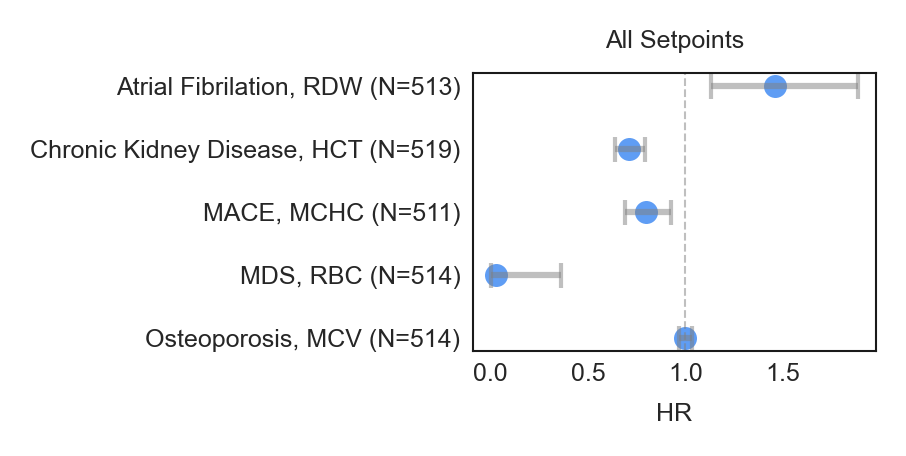

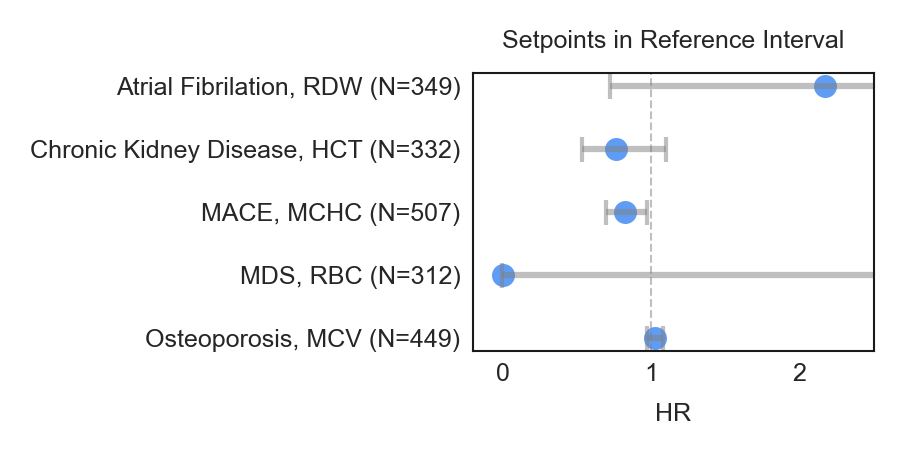

In [37]:
# Create empty list to store all results
all_results = []

# Dictionary to map biomarkers to their corresponding disease endpoints
biomarker_disease_map = {
    'RDW': 'chronic_heart_disease_diagnosis_time',
    'HCT': 'chronic_kidney_disease_diagnosis_time',
    'MCHC': 'MACE_diagnosis_time',
    'RBC': 'MDS_diagnosis_time',
    'MCV': 'osteoporosis_diagnosis_time'
}

titles = {'chronic_heart_disease_diagnosis_time': 'Atrial Fibrilation',
          'chronic_kidney_disease_diagnosis_time': 'Chronic Kidney Disease',
          'MACE_diagnosis_time': 'MACE',
          'MDS_diagnosis_time': 'MDS',
          'osteoporosis_diagnosis_time': 'Osteoporosis'}
# Run analysis for each biomarker-disease pair
for biomarker, disease_time in biomarker_disease_map.items():
    result_df = run_cox_model_diag(
        min_days, 
        min_test, 
        year_cutoff, 
        biomarker, 
        biomarker='setpoint', 
        end_col=disease_time
    ).reset_index()
    # Add biomarker and disease columns
    result_df['biomarker'] = biomarker
    result_df['disease'] = titles[disease_time]
    all_results.append(result_df)

# Combine all results
combined_results = pd.concat(all_results, ignore_index=True)

# Display the combined results
print("Combined Results:")
display(combined_results)

# Optionally save to CSV
combined_results_all = combined_results.query('index == "All Setpoints"')
plot_hr(combined_results_all, 'All Setpoints')

combined_results_all = combined_results.query('index != "All Setpoints"')
plot_hr(combined_results_all, 'Setpoints in Reference Interval')
plt.xlim(-0.2, 2.5)


In [41]:
biomarker_disease_map

{'RDW': 'chronic_heart_disease_diagnosis_time',
 'HCT': 'chronic_kidney_disease_diagnosis_time',
 'MCHC': 'MACE_diagnosis_time',
 'RBC': 'MDS_diagnosis_time',
 'MCV': 'osteoporosis_diagnosis_time'}

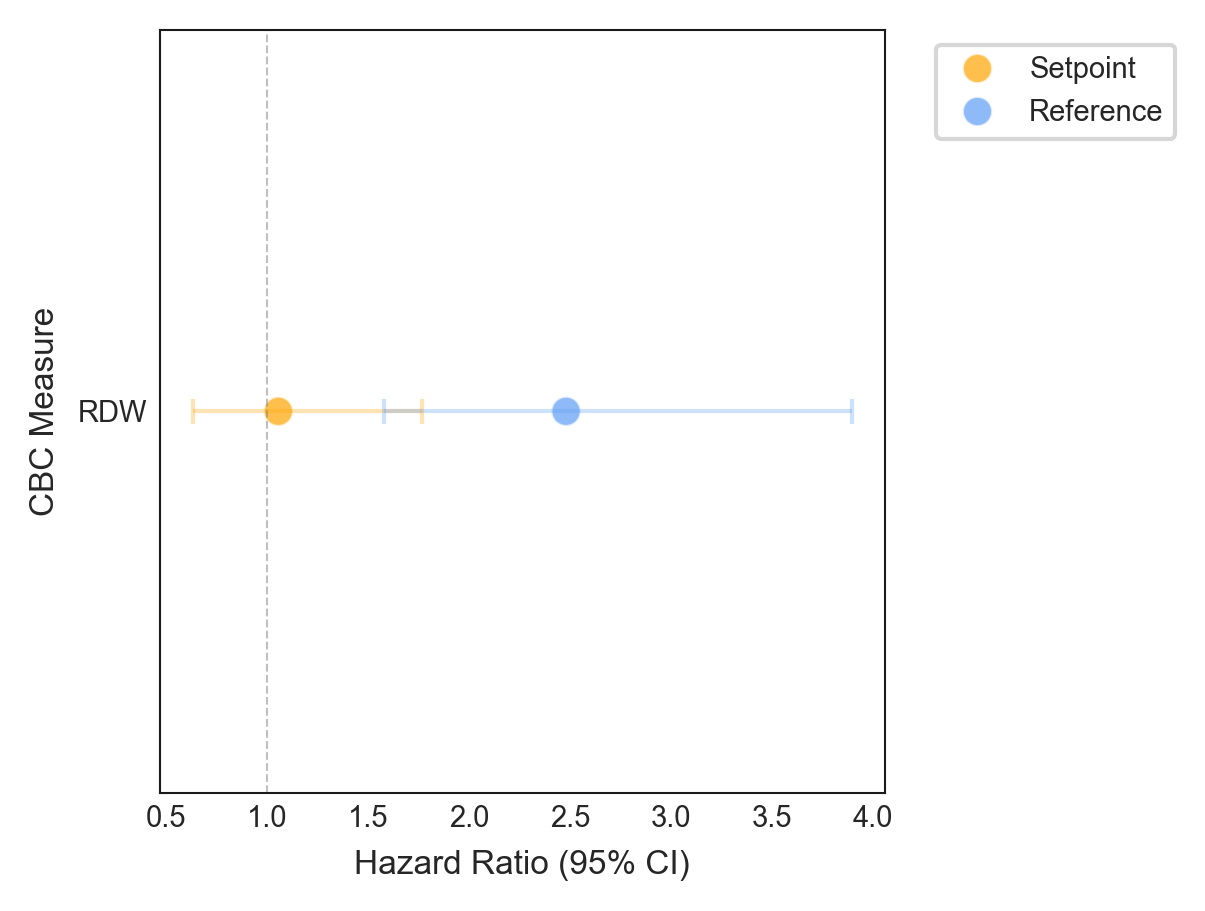

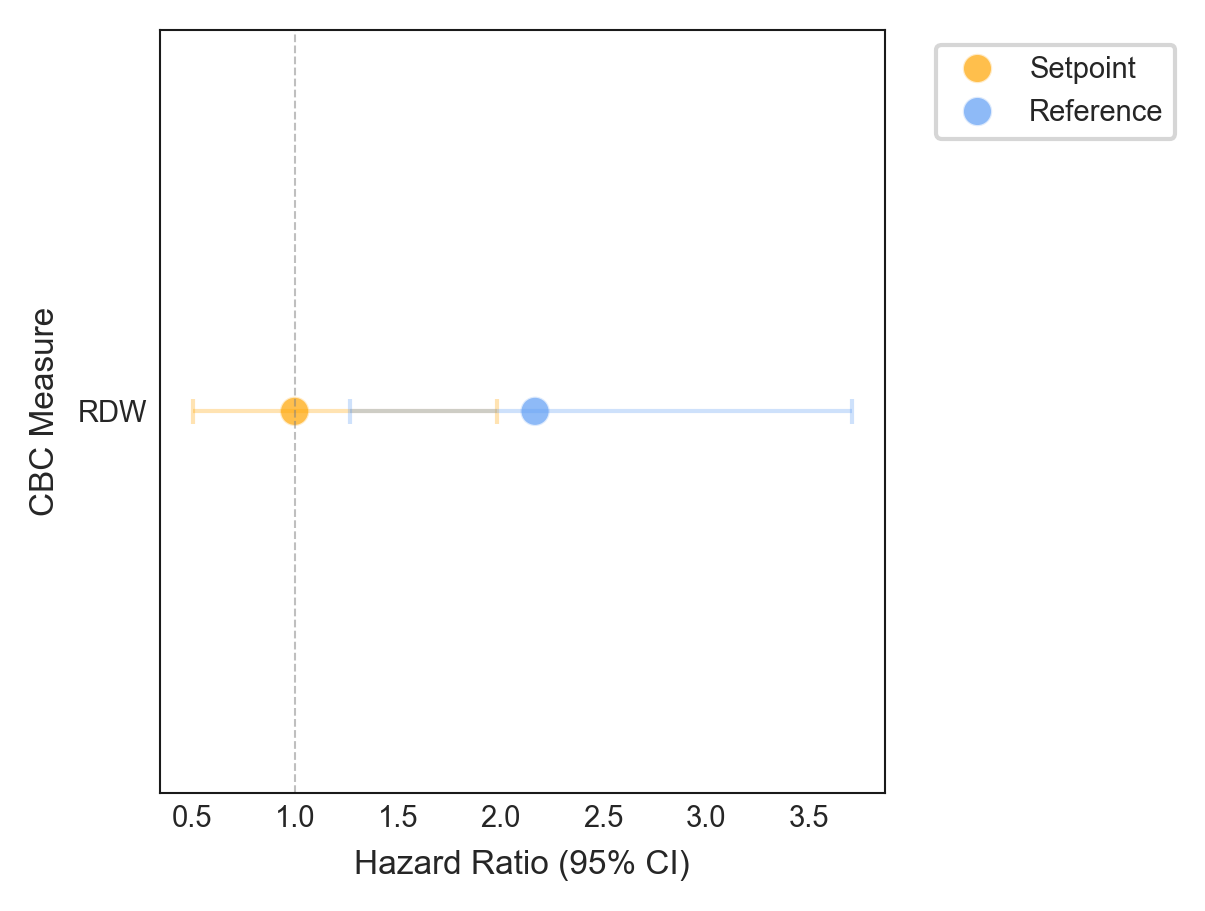

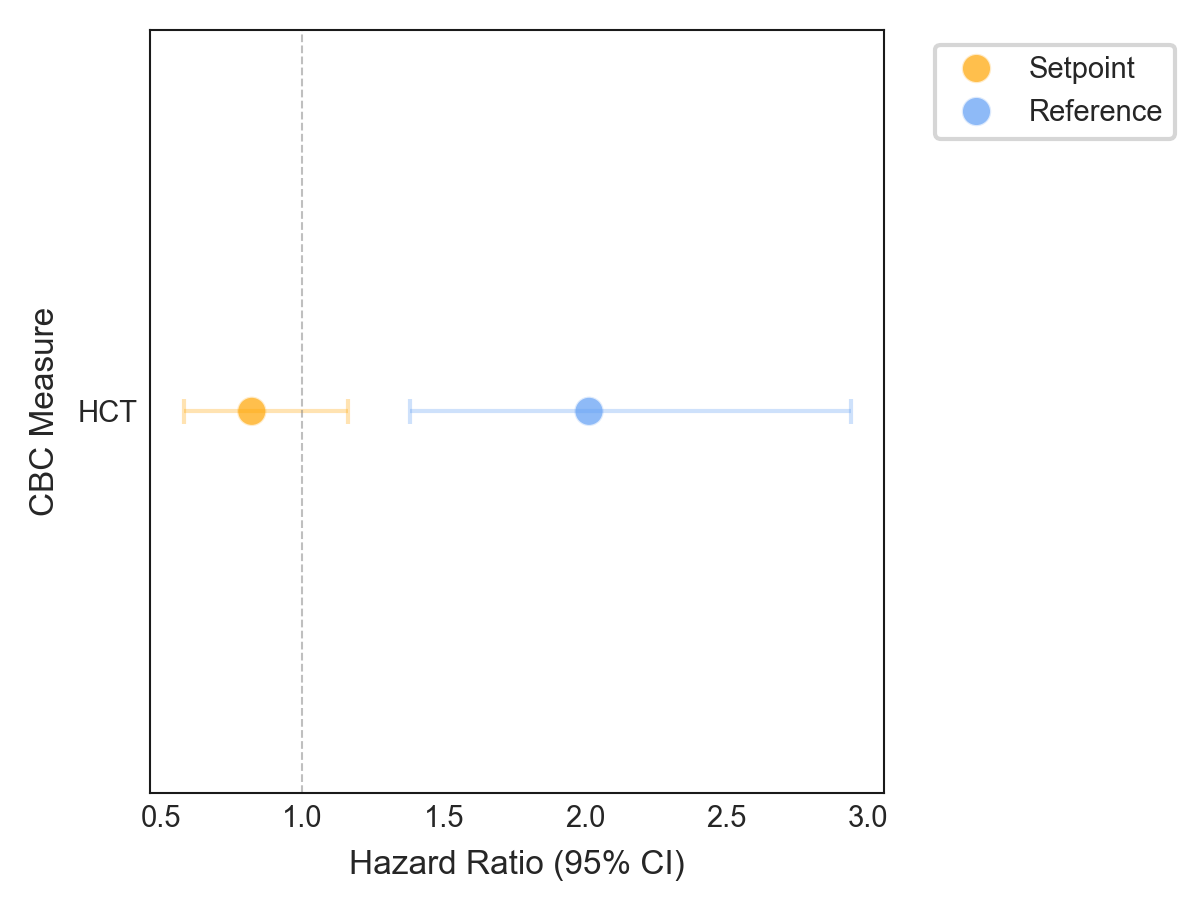

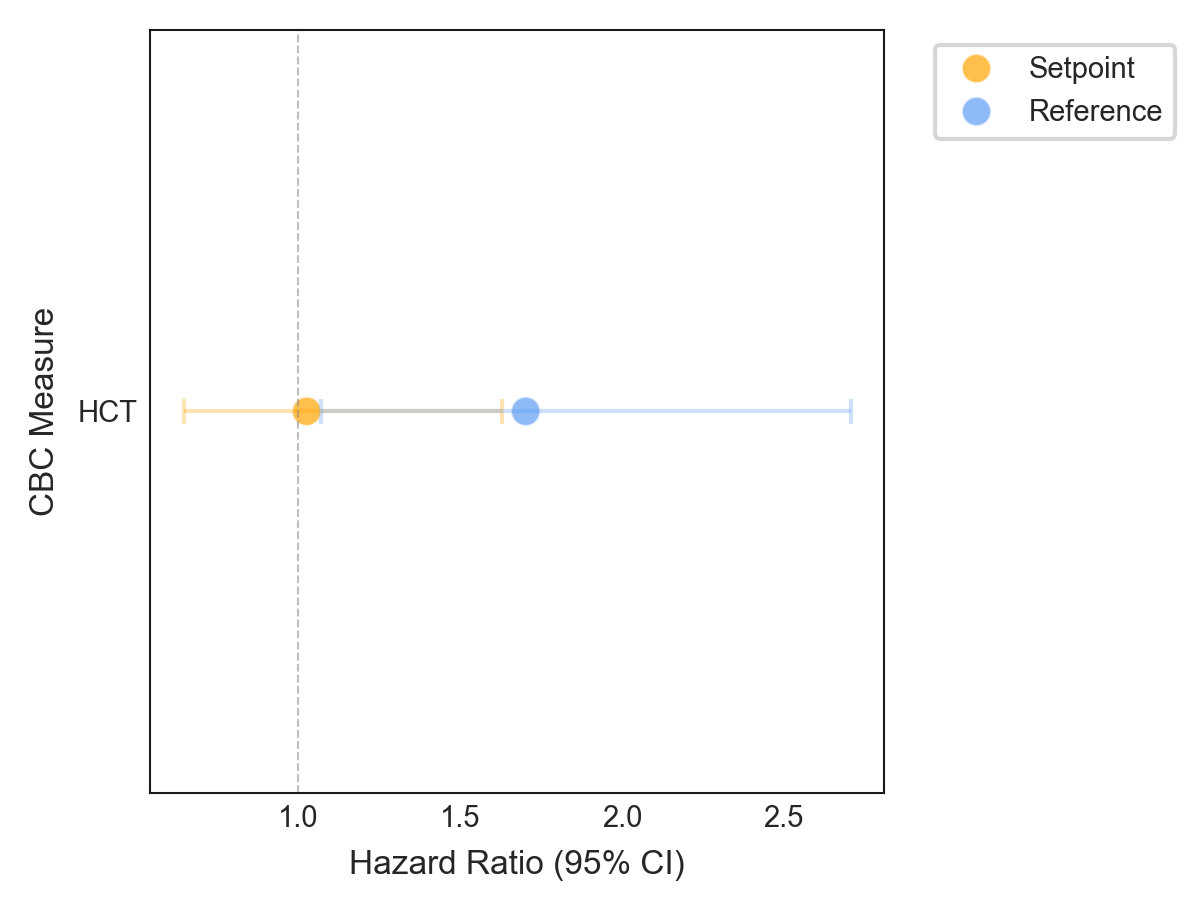

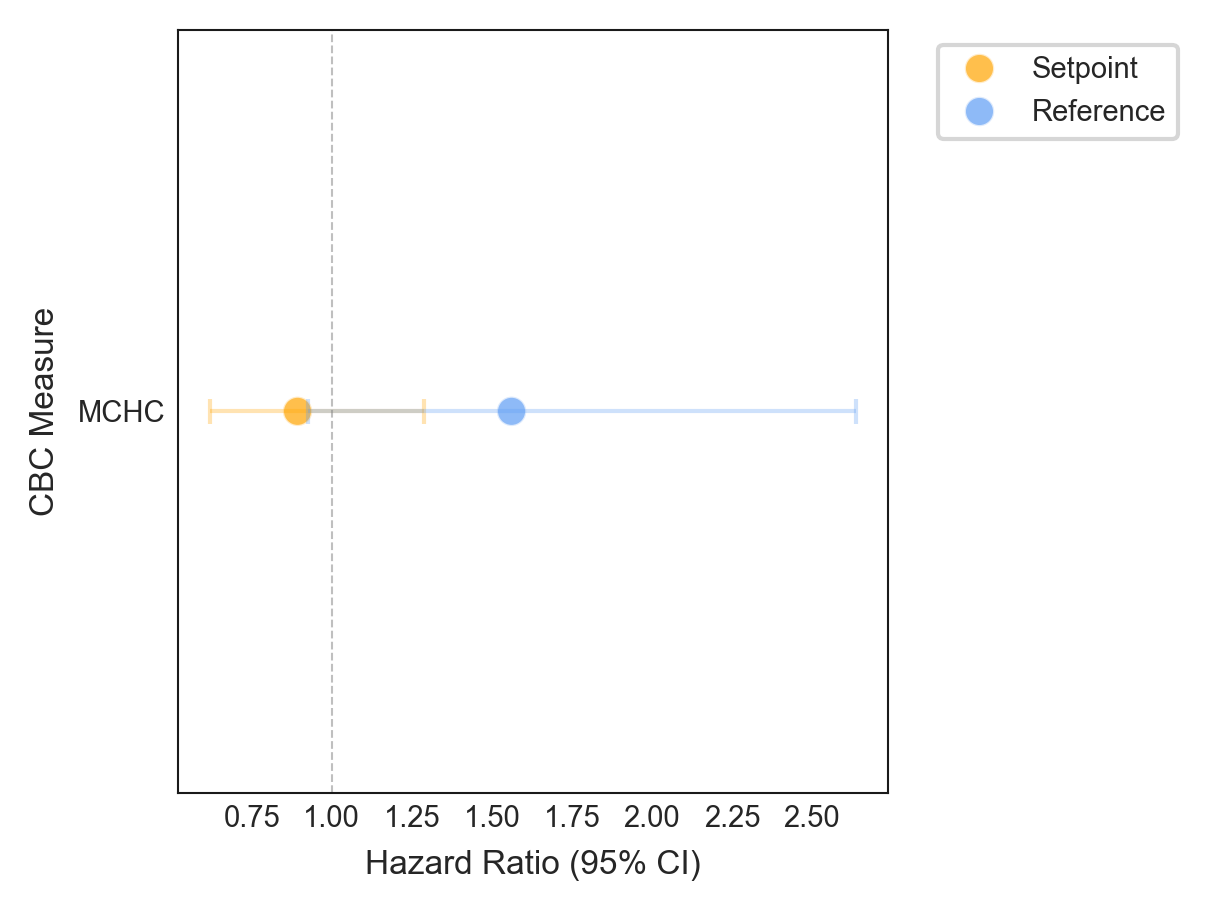

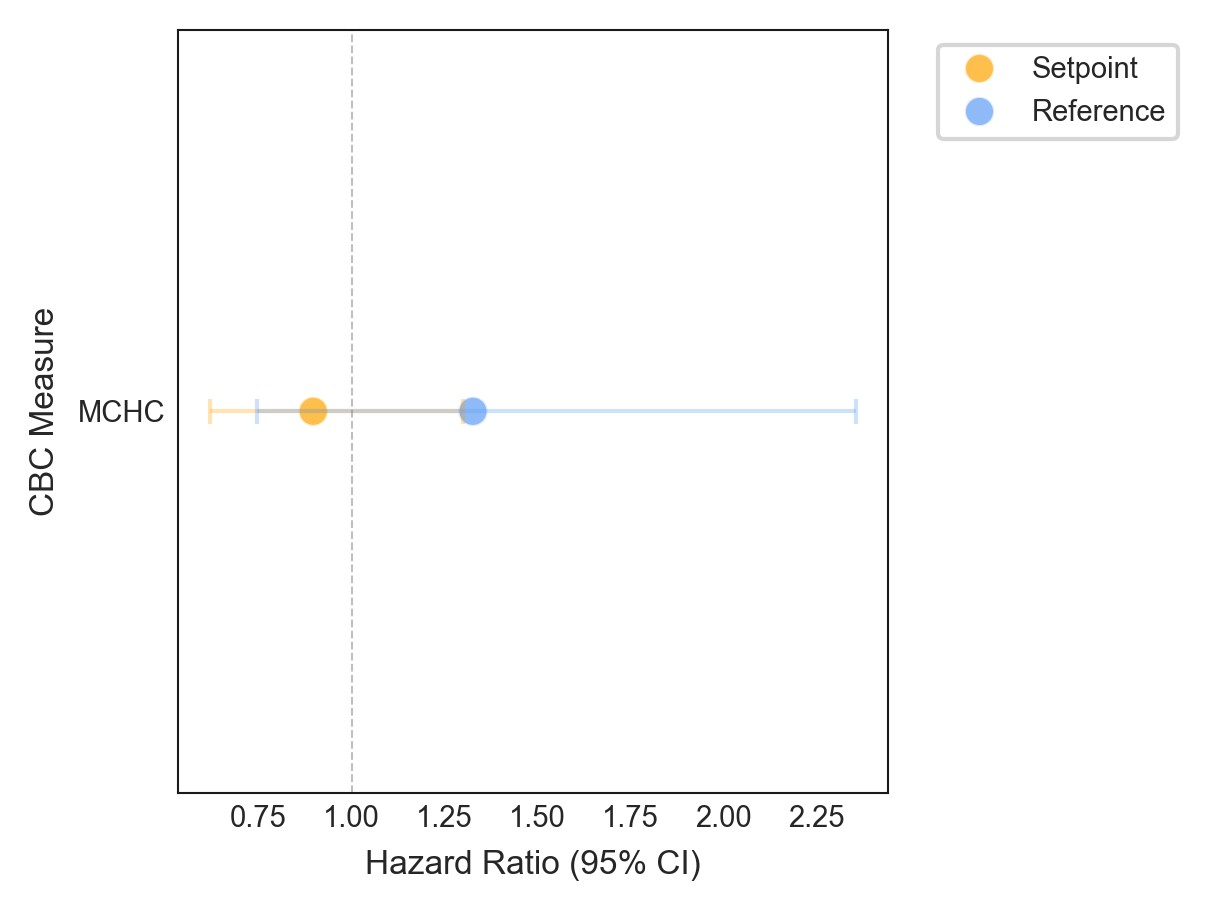

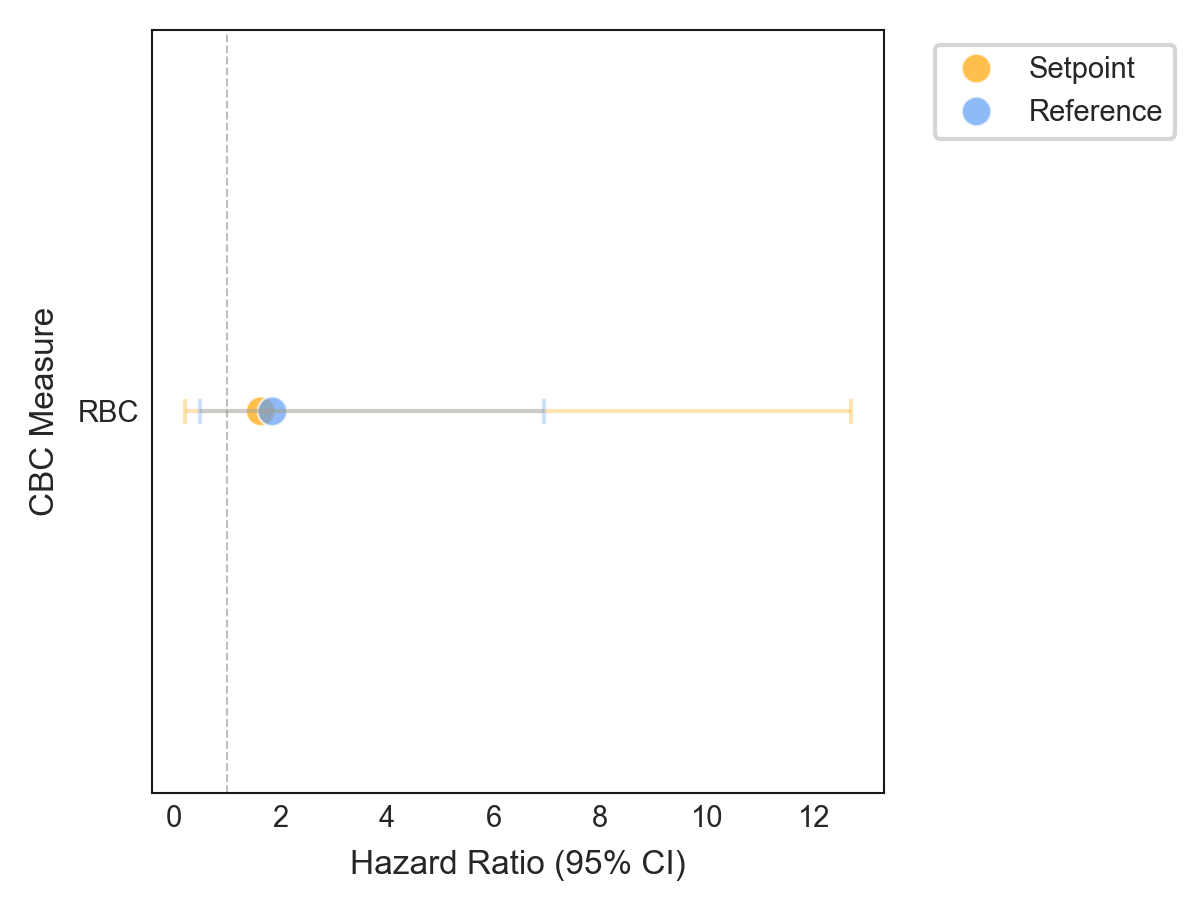

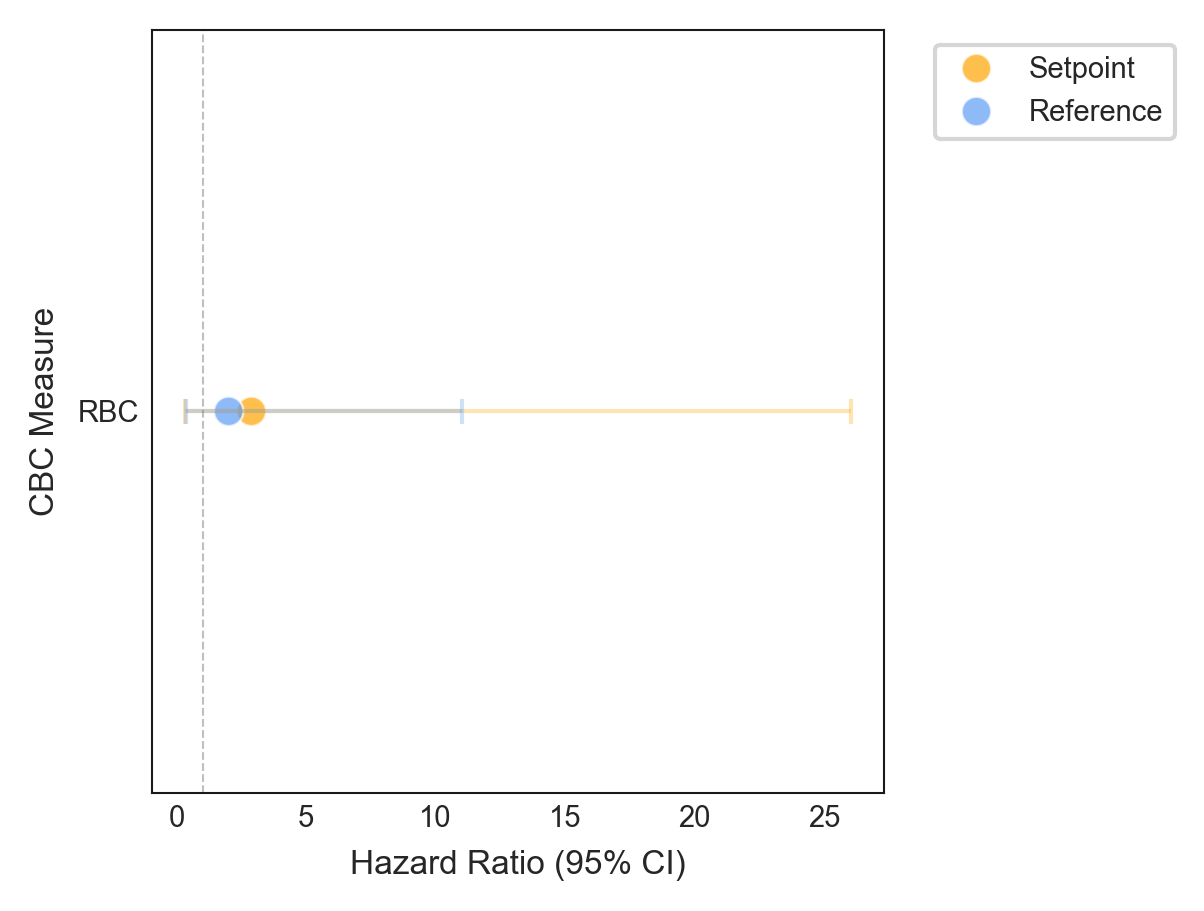

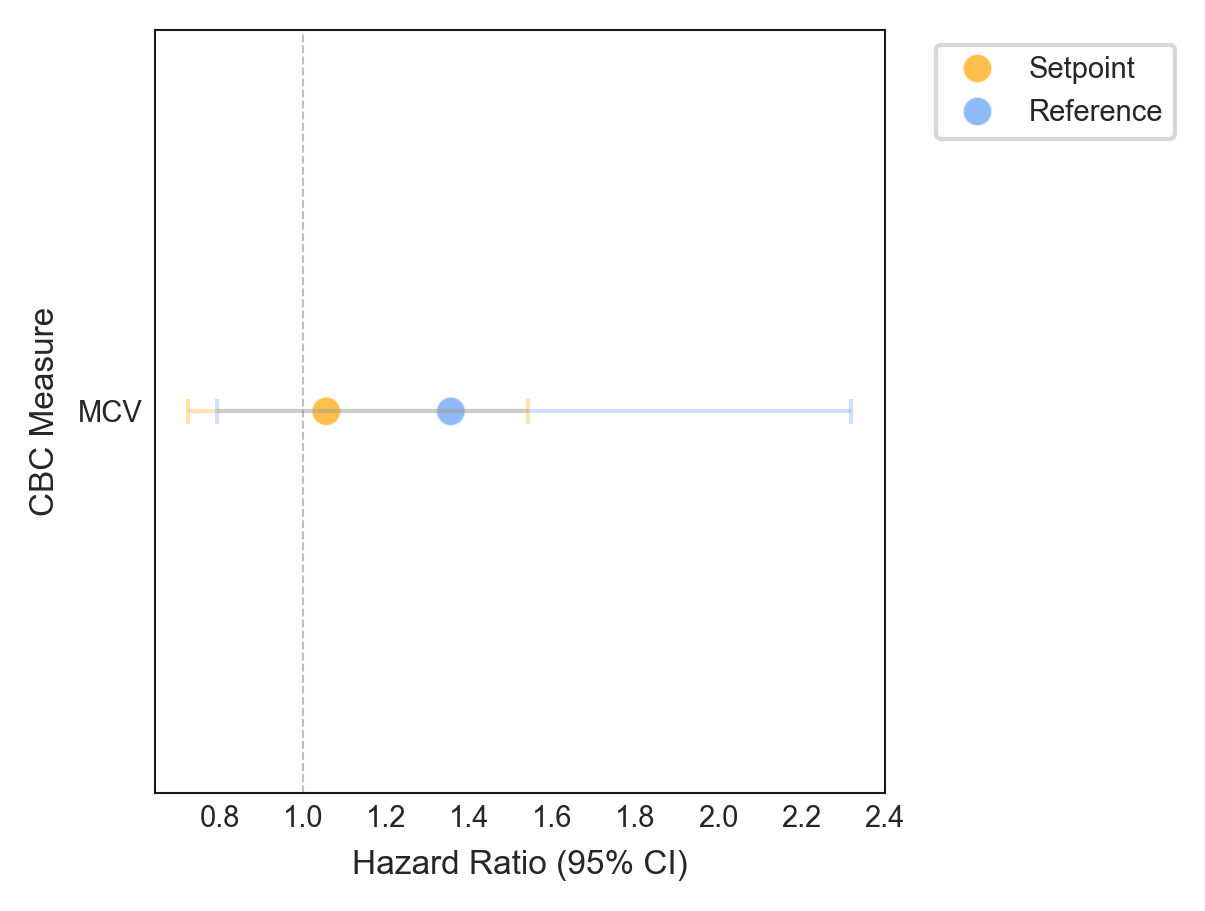

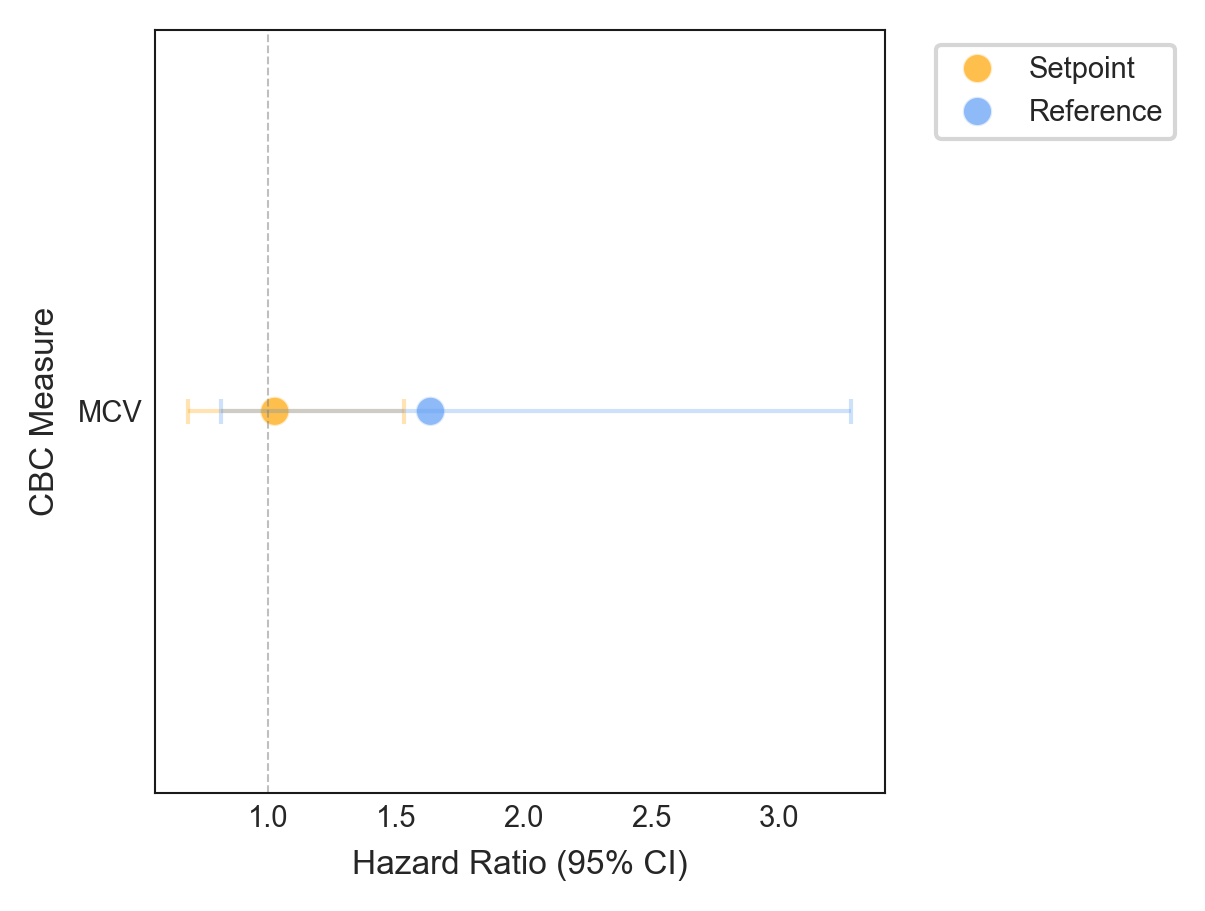

In [46]:
min_time_since_setpoint = 365
max_time_since_setpoint = 365*3

for biomarker, disease_time in biomarker_disease_map.items():
    result_df, reference_df = run_interval_cox_analysis_diag(
        min_days, 
        min_test, 
        year_cutoff, 
        code=biomarker,
        min_time_since_setpoint=min_time_since_setpoint,
        max_time_since_setpoint=max_time_since_setpoint,
        covariates=[],
        end_col=disease_time
    ) #.reset_index()
    # Add biomarker and disease columns
    #result_df['biomarker'] = biomarker
    #result_df['disease'] = titles[disease_time]
    #all_results.append(result_df)

In [30]:
# Being out

Index(['subject_id', 'code', 'setpoint', 'cv', 'std', 'model_type',
       'year_cutoff', 'min_gap', 'min_tests', 'setpoint_estimation_time',
       'number_of_measurements', 'time_period', 'gender', 'dob', 'race',
       'ethnicity', 'observation_period_end_time', 'time_of_death', 'time',
       'unit', 'numeric_value', 'within_reference', 'BMI',
       'BMI_category_Morbid Obesity', 'BMI_category_Obesity',
       'BMI_category_Overweight', 'BMI_category_Severe Obesity',
       'BMI_category_Underweight', 'within_setpoint', 'setpoint_in_interval'],
      dtype='object')